<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/A3_Salinity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Statistical Analysis of Salinity Trends

**How has salinty changed over time at victoria's western port, and what isstatistical evidence supports the presence or absence of a long‑term trend?**

Salinity shifts serve as a primary physical indicator and consequence of climate change. As global temperatures rise, the water cycle accelerates—evaporation intensifies in dry subtropics while high-latitude regions experience increased precipitation and glacial melt. This fundamentally alters the salt balance in global waters and coastal soils. Changes in salinity serve as an early warning sign for climate change.

**This project aims to analyse a dataset of salinty to:**

compute salinty trends

quantify uncertainty using bootstrapping

simulate possible future salinty paths using Monte Carlo methods

use bayes theorem to examine mean difference

model long‑term trends using Bayesian regression

examine temporal structure using time‑series analysis

**Hypothesis:**

That the salinty at victoria's western port has increased.

This can be inferred due a variety of factors. First, is decreased rainfall, which lowers the amount of fresh water mixing into the bay, allowing denser marine water to dominate the system. Simultaneously, rising tides push salty groundwater closer to the surface, where evaporation concentrates salt in the soil root zones, ultimately threatening local coastal ecosystems, agricultural productivity, and infrastructure.


**Datasets used:**

Name of dataset used: *'EPA Western Port Water Quality Data 1990 - 2025
'*

UNCLEANED DATA SET: https://discover.data.vic.gov.au/dataset/epa-western-port-water-quality-data


CLEANED DATA SET: https://anu365-my.sharepoint.com/:x:/g/personal/u8216285_anu_edu_au/IQDP-tY6SH3uRbwQQZ3TutJZAX8T700pbnxJimA4K-waja4?e=xyzpmM

##Imports & Data Loading:

In [173]:
!pip install bambi #system command to install bambi package

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import bambi as bmb
import arviz as az

from scipy import stats
import pymc as pm


In [175]:
# Load daily temperature data
spreadsheet_name = "wpdata.xlsx"
worksheet_name = "Data"

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

# Clean column names
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")

df.head()

,SITE_ID,SITE_NAME_SHORT,WATER_BODY,DATE,TYPE,CHL_A,SECCHI_DEPTH_M,DO_MG,FL,PAR,...,PH,TSS,N_NH3,N_NO2,N_NO3,N_NOX,N_TOTAL,P_PO4,P_TOTAL,SI
0,709,Hastings,Western Port,1990-02-28,surface,1.30,2.0,7.18,NaN,NaN,...,NaN,5.09,14.62,1.09,4.92,6.02,181.67,4.73,12.71,96.92
1,716,Barralier Island,Western Port,1990-02-28,surface,1.45,2.0,6.97,NaN,NaN,...,NaN,6.23,12.46,1.12,3.69,4.81,216.92,2.86,13.39,100.34
2,724,Corinella,Western Port,1990-02-28,surface,1.68,1.0,6.33,NaN,NaN,...,NaN,21.91,8.68,0.78,5.34,6.11,265.51,3.80,26.51,19.67
3,724,Corinella,Western Port,1990-04-03,surface,1.48,0.5,7.21,NaN,NaN,...,8.1,14.24,20.74,2.65,9.13,11.77,267.22,6.54,38.24,326.89
4,709,Hastings,Western Port,1990-04-04,surface,1.30,2.0,7.11,NaN,NaN,...,8.2,7.23,9.90,0.97,3.29,4.26,172.10,6.09,27.72,105.31


##Data Check & Location Selection:

In [176]:
# How many observations per location?
df["SITE_NAME_SHORT"].value_counts()

,count
SITE_NAME_SHORT,
Corinella,385
Hastings,380
Barralier Island,265


In [177]:
loc_types = ["Corinella", "Hastings"]
loc_1, loc_2 = loc_types
print("Locations used:", loc_types)

Locations used: ['Corinella', 'Hastings']


In [178]:
# Create numeric time variable (year + fraction of year)
df["TIME_FLOAT"] = df["DATE"].dt.year + (df["DATE"].dt.month - 1) / 12

loc_col = "SITE_NAME_SHORT"
x_col = "TIME_FLOAT"
y_col = "SAL"

# Filter to the two locations and keep only needed columns
data = df[df[loc_col].isin([loc_1, loc_2])].copy()
data = data[[loc_col, x_col, y_col]].dropna()

Data handling:
- Sorting ensures time‑series methods behave correctly.

- Computing mean temperature from min/max is standard practice when hourly data is unavailable.

- Missing values should be checked and removed or imputed depending on context.

##Exploratory Plot:

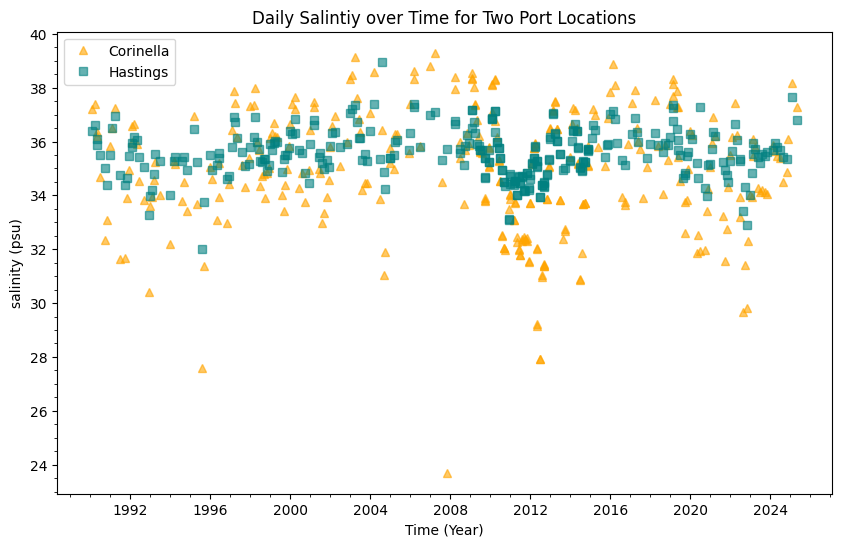

In [179]:
colors = ["orange", "teal"]

plt.figure(figsize=(10, 6))
for loc, c, marker in zip([loc_1, loc_2], colors, ["^", "s"]):
    subset = data[data[loc_col] == loc]
    plt.plot(subset[x_col], subset[y_col], marker, alpha=0.6, color=c, label=loc)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel("Time (Year)")
plt.ylabel("salinity (psu)")
plt.legend()
plt.ylim()
plt.minorticks_on()
plt.title("Daily Salintiy over Time for Two Port Locations")
plt.show()


**Figure 1:** Scatter plot of salinity observations over time for Corinella and Hastings, used to visually inspect trends and differences before any formal modelling.

Observations
- Stable around 36 psu.

- No clear trend of data - graph influence by outliers.

- Variability appears stable for Hastings, but there are significant variations for Corinella, with many outliers.

##Bootstrap:

In [180]:
# Use all mean temperatures from the two locations
X = data[y_col].values

np.random.seed(42)
B = np.random.choice(X, size=(len(X), 1000), replace=True)

bar = np.mean(B, axis=0)
print("Bootstrap means created:", bar.shape)

Bootstrap means created: (1000,)


95% confidence interval: [35.09607205 35.35433683]


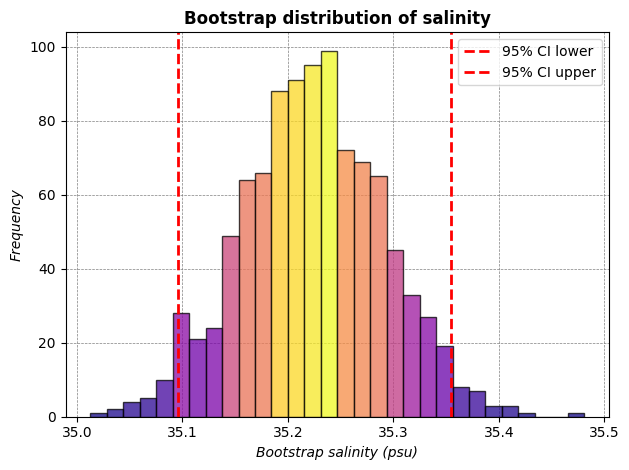

In [181]:
from matplotlib import colors as mcolors

fig, ax = plt.subplots(tight_layout=True)
n, bins, patches = ax.hist(
    bar,
    bins=30,
    edgecolor="k",
    alpha=0.75
)

fracs = n / n.max()
norm = mcolors.Normalize(fracs.min(), fracs.max())
for thisfrac, thispatch in zip(fracs, patches):
    color = plt.cm.plasma(norm(thisfrac))
    thispatch.set_facecolor(color)

ax.set_axisbelow(True)
ax.grid(color="gray", linestyle="dashed", linewidth=0.5)

plt.xlabel("Bootstrap salinity (psu)", style="italic")
plt.ylabel("Frequency", style="italic")
plt.title("Bootstrap distribution of salinity", fontweight="bold")

ci = np.percentile(bar, [2.5, 97.5])
print("95% confidence interval:", ci)

plt.axvline(ci[0], color="red", linestyle="dashed", linewidth=2, label="95% CI lower")
plt.axvline(ci[1], color="red", linestyle="dashed", linewidth=2, label="95% CI upper")
plt.legend()
plt.show()


**Interpretation:** The bootstrap distribution shows the uncertainty around the overall salinity. The 95% CI quantifies plausible values for the mean without assuming normality.

##Hypothesis Testing

In [206]:
#SELECT EARLY YEAR GROUPS FROM THE DATASET

data_early = df[(df[x_col] <= 2007)][y_col].dropna()
data_early = data_early[data_early>0]

#SELECT RECENT YEAR GROUPS FROM THE DATASET
data_recent = df[(df[x_col] > 2007)][y_col].dropna()
data_recent = data_recent[data_recent>0]

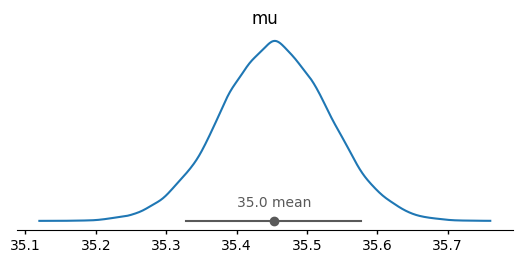

In [209]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR EARLY YEARS

with pm.Model() as early_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 20.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_early)

   # Obtain 20,000 samples from the posterior
  trace_early = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
az.plot_dist(trace_early, var_names=["mu"]) # Corrected: Passing InferenceData object with var_names

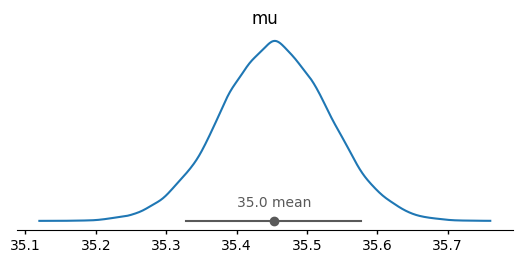

In [210]:
#BAYESIAN MODEL ESTIMATING MEAN CATCH FOR RECENT YEARS

with pm.Model() as recent_model:

  # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
  mu = pm.Normal("mu", mu = 3, sigma = 2)

  # Prior for std of heights — HalfNormal with a standard deviation of 20.
  sigma = pm.HalfNormal ("sigma", sigma = 2)

  # Likelihood given the data
  obs = pm.Normal ("obs", mu = mu, sigma = sigma, observed = data_recent)

   # Obtain 20,000 samples from the posterior
  trace_recent = pm.sample(20000, tune = 2000, return_inferencedata = True, progressbar = False)

  # Plot the posterior distribution for the mean
  az.plot_dist(trace_early, var_names=["mu"]) # Corrected: Passing InferenceData object with var_names

In [211]:
#EXTRACT POSTERIOR SAMPLES OF THE MEAN FROM BOTH MODELS

mu_samples_early = trace_early.posterior["mu"].values.flatten()
mu_samples_recent = trace_recent.posterior["mu"].values.flatten()

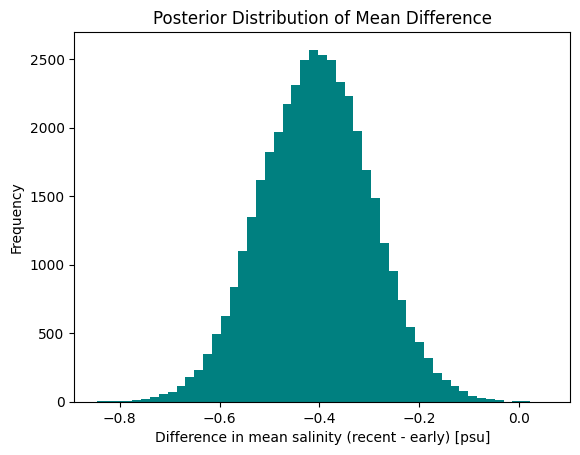

In [213]:
#PLOT DISTRIBUTION OF DIFFERENCE IN MEAN CATCH BETWEEN GROUPS
mu_diff = mu_samples_recent - mu_samples_early

#HISTOGRAM
plt.hist(mu_diff, bins = 51, color="teal")

#LABELS
plt.xlabel("Difference in mean salinity (recent - early) [psu]")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Mean Difference")

#SHOW
plt.show() #show plot

In [215]:
#CALCULATE THE 95% HIGHEST DENSITY INTERVAL (CREDIBLE INTERVAL)

az.hdi(mu_diff, prob = 0.95)

array([-0.61263091, -0.18441229])

In [216]:
#CALCULATE PROBABILITY THAT RECENT MEAN CATCH IS GREATER THAN EARLY MEAN CATCH

np.mean(mu_diff > 0)

np.float64(0.000175)

The probability of the mean catch rate being higher that the previous catch
rate is ~0.000175, meaning their is no significant increase in the catch rate between the two data sets and our hypothesis has been disproven.

##Scaling and polynomial terms:

In [182]:
# Scale time for numerical stability
data["x_scaled"] = (data[x_col] - data[x_col].mean()) / data[x_col].std()
data["x2_scaled"] = data["x_scaled"] ** 2
data["x3_scaled"] = data["x_scaled"] ** 3

##Bayesian regression models (linear, quadratic, cubic):

In [183]:
# Linear
model_linear = bmb.Model(f"{y_col} ~ x_scaled * {loc_col}", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Quadratic
model_quadratic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled * {loc_col}", data)
idata_quadratic = model_quadratic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Cubic
model_cubic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled + x3_scaled * {loc_col}", data)
idata_cubic = model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)


/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


In [184]:
cmp = az.compare(
    {"linear": idata_linear, "quadratic": idata_quadratic, "cubic": idata_cubic},
    method="BB-pseudo-BMA"
)
cmp

,rank,elpd,p,elpd_diff,weight,se,dse,warning
cubic,0,-1270.0,8.1,0.0,0.67,32.0,0.0,False
linear,1,-1270.0,6.7,-2.0,0.25,32.0,2.4,False
quadratic,2,-1270.0,7.7,-3.0,0.08,32.0,2.3,False


The cubic model (rank 0) provided the best fit to the relationship between time and salinity across the two locations.

##Priors and posteriors:

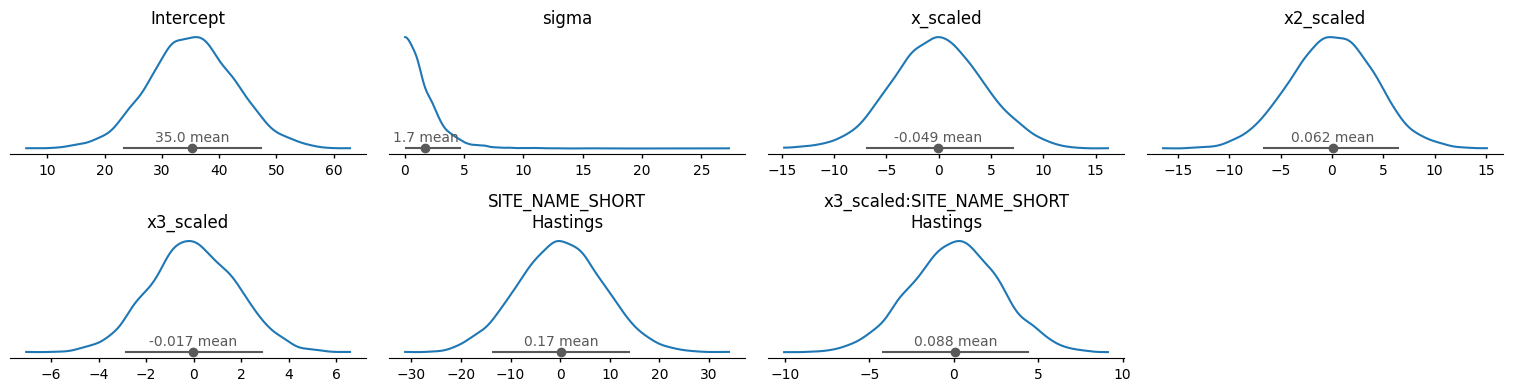

In [185]:
model_cubic.plot_priors()
plt.tight_layout()
plt.show()

 Priors for the cubic regression model. They are broad and centred around zero, reflecting weak prior assumptions about the direction and strength of the temperature trend.

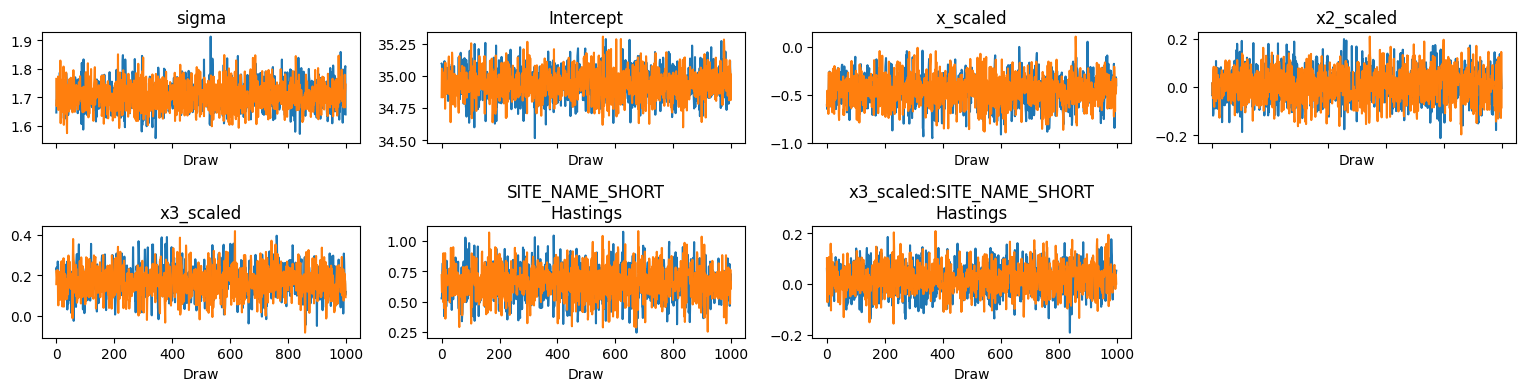

In [186]:
az.plot_trace(idata_cubic)
plt.tight_layout()
plt.show()

**Figure 3:** Posterior trace plots for the cubic model. The chains mix well and converge, suggesting the model has sampled the posterior reliably.

##Predictions + HDIs:

In [187]:
x_range = np.linspace(data[x_col].min(), data[x_col].max(), 200)
x_range_scaled = (x_range - data[x_col].mean()) / data[x_col].std()
x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

In [188]:
# Predictions for location 1
new_data_loc1 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_1
})
idata_pred_loc1_params = model_cubic.predict(idata_cubic,
                                             data=new_data_loc1,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc1_resp = model_cubic.predict(idata_cubic,
                                           data=new_data_loc1,
                                           kind="response",
                                           inplace=False)

mu_draws_loc1 = idata_pred_loc1_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc1 = idata_pred_loc1_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T

posterior_mean_loc1 = pps_draws_loc1.mean(axis=0)
hdi_mean_loc1 = az.hdi(mu_draws_loc1, prob=0.95, axis=0)
hdi_pps_loc1 = az.hdi(pps_draws_loc1, prob=0.95, axis=0)

In [189]:
# Predictions for location 2
new_data_loc2 = pd.DataFrame({
    "x_scaled": x_range_scaled,
    "x2_scaled": x2_range_scaled,
    "x3_scaled": x3_range_scaled,
    loc_col: loc_2
})
idata_pred_loc2_params = model_cubic.predict(idata_cubic,
                                             data=new_data_loc2,
                                             kind="response_params",
                                             inplace=False)
idata_pred_loc2_resp = model_cubic.predict(idata_cubic,
                                           data=new_data_loc2,
                                           kind="response",
                                           inplace=False)

mu_draws_loc2 = idata_pred_loc2_params.posterior["mu"].stack(draws=("chain","draw")).values.T
pps_draws_loc2 = idata_pred_loc2_resp.posterior_predictive[y_col].stack(draws=("chain","draw")).values.T


posterior_mean_loc2 = pps_draws_loc2.mean(axis=0)
hdi_mean_loc2 = az.hdi(mu_draws_loc2, prob=0.95, axis=0)
hdi_pps_loc2 = az.hdi(pps_draws_loc2, prob=0.95, axis=0)

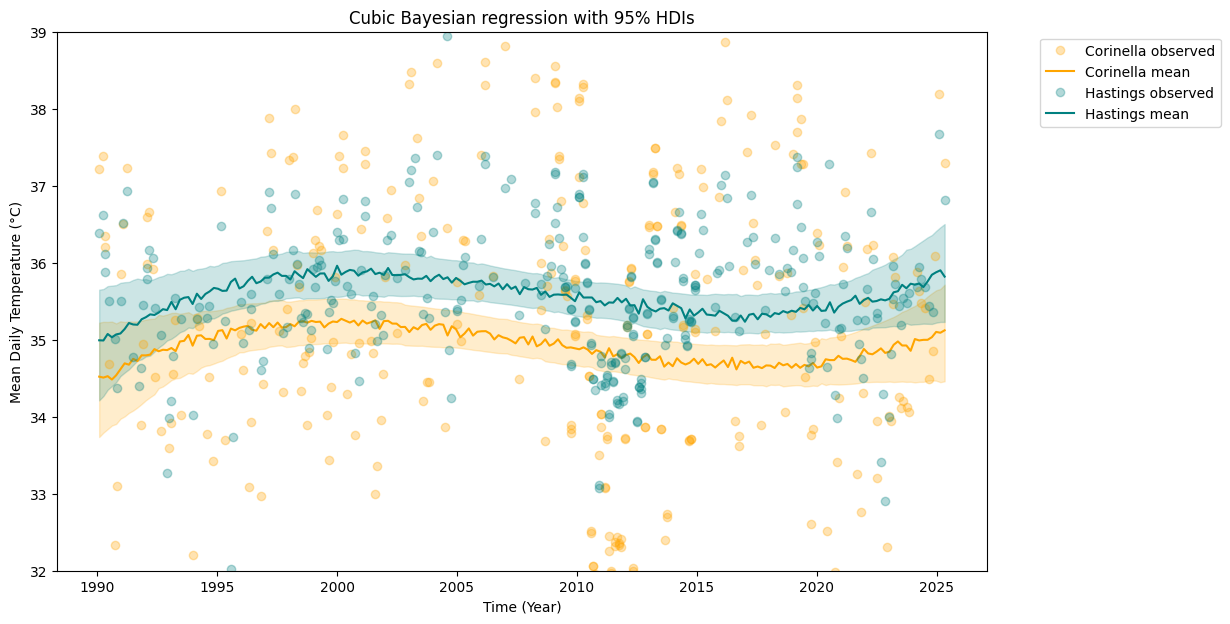

In [191]:
plt.figure(figsize=(12, 7))

for loc, c, mean, hdi_m in [
    (loc_1, colors[0], posterior_mean_loc1, hdi_mean_loc1),
    (loc_2, colors[1], posterior_mean_loc2, hdi_mean_loc2),
]:
    subset = data[data[loc_col] == loc]
    plt.plot(subset[x_col], subset[y_col], "o", color=c, alpha=0.3, label=f"{loc} observed")
    plt.plot(x_range, mean, color=c, label=f"{loc} mean")
    plt.fill_between(x_range, hdi_m[:, 0], hdi_m[:, 1], alpha=0.2, color=c)
plt.ylim(32, 39)
plt.xlabel("Time (Year)")
plt.ylabel("Salinity (psu)")
plt.title("Cubic Bayesian regression with 95% HDIs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Figure 4:** Fitted cubic regression curves with 95% HDIs for both locations. The model captures gradual changes in salinity over time and quantifies uncertainty around the trend.